<a href="https://colab.research.google.com/github/chandradharvasireddy-19/25BDS0329/blob/main/exp8_15.09.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from scipy.cluster.hierarchy import dendrogram, linkage
from pandas.plotting import parallel_coordinates, andrews_curves

df = pd.read_csv("/usuarios-de-redes-sociales-por-pas-en-2026.csv")
df.head(3)

,flagCode,country,SocialMediaUsers_2025,SocialMediaUsersPctOfPopulation_2025
0,CN,China,1280000000,90.3
1,IN,India,500000000,34.1
2,US,United States,254000000,73.0


In [30]:
#dropping missing rows
df = df.dropna(subset=['country']).reset_index(drop=True)
df = df[df['country'] != 'Total'].reset_index(drop=True)
df
def build_tier(pct):
    if pct >= 75: return 'High Growth (75%+)'
    elif pct >= 40: return 'Developing (40-74%)'
    else: return 'Emerging Stage (<40%)'

df['Penetration_Tier'] = df['SocialMediaUsersPctOfPopulation_2025'].apply(build_tier)

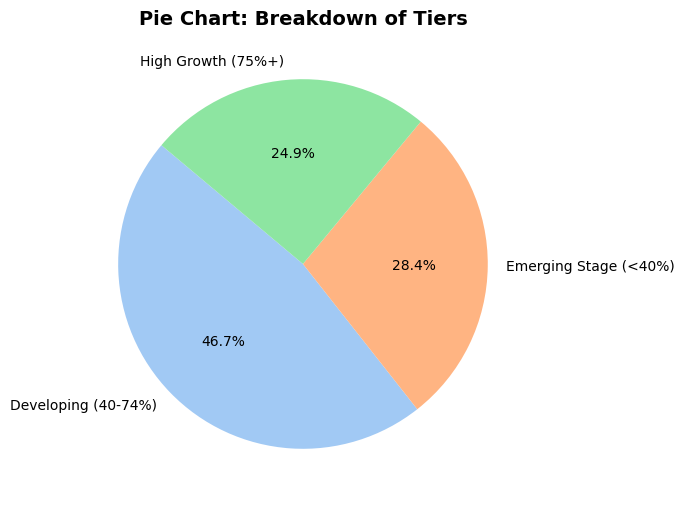

In [16]:
#pie chart
def plot_pie(data, labels, title="Pie Chart"):
    plt.figure(figsize=(6, 6))
    plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title(title, fontsize=14, fontweight='bold')
    plt.show()
tier_counts = df['Penetration_Tier'].value_counts()
plot_pie(data=tier_counts.values, labels=tier_counts.index, title="Pie Chart: Breakdown of Tiers")

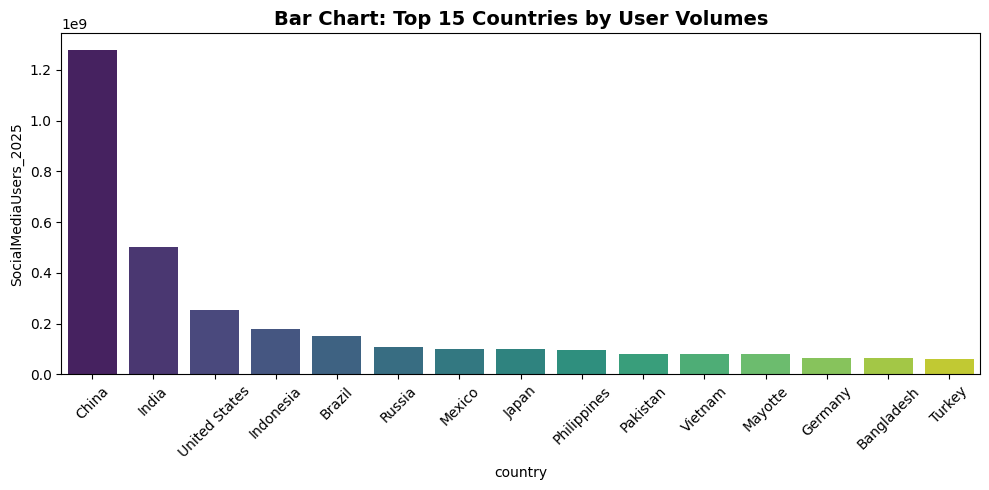

In [17]:
#bar chart
def plot_bar(categories, values, title="Bar Chart"):
    plt.figure(figsize=(10, 5))
    sns.barplot(x=categories, y=values, palette='viridis', hue=categories, legend=False)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
top_15_countries = df.head(15)
plot_bar(categories=top_15_countries['country'], values=top_15_countries['SocialMediaUsers_2025'], title="Bar Chart: Top 15 Countries by User Volumes")

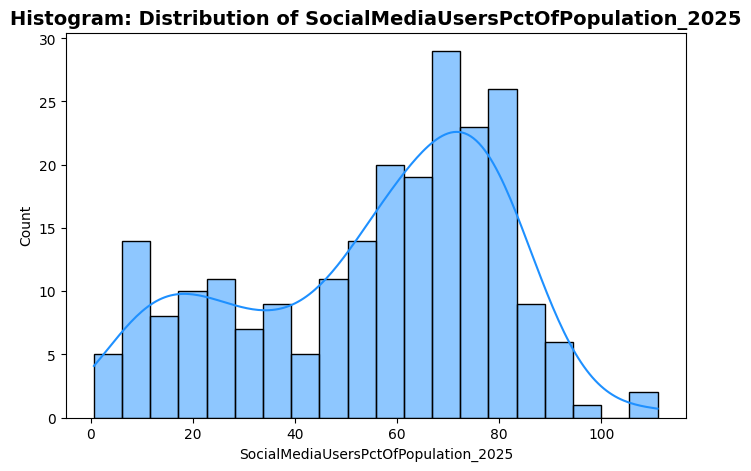

In [18]:
#histogram
def plot_histogram(df, column):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True, color='dodgerblue', bins=20)
    plt.title(f"Histogram: Distribution of {column}", fontsize=14, fontweight='bold')
    plt.show()
plot_histogram(df, column='SocialMediaUsersPctOfPopulation_2025')

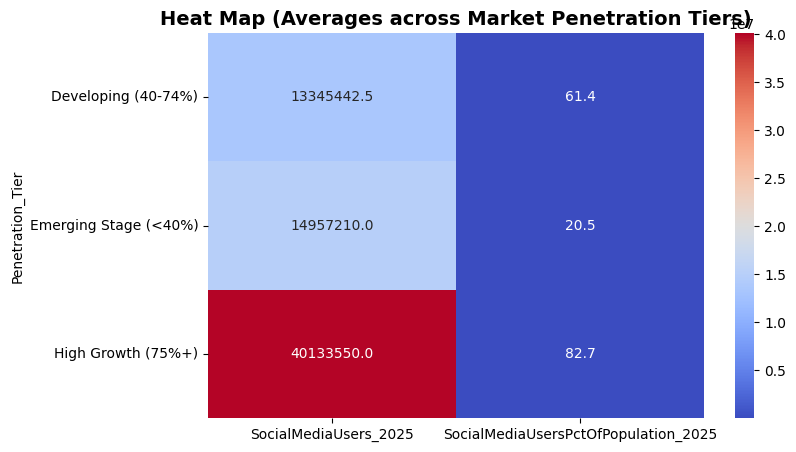

In [19]:
#heat map
def heatmap(df, annot=True, cmap='coolwarm'):
    plt.figure(figsize=(8, 5))
    pivot_df = df.groupby('Penetration_Tier')[['SocialMediaUsers_2025', 'SocialMediaUsersPctOfPopulation_2025']].mean()
    sns.heatmap(pivot_df, annot=annot, cmap=cmap, fmt=".1f")
    plt.title("Heat Map (Averages across Market Penetration Tiers)", fontsize=14, fontweight='bold')
    plt.show()
heatmap(df, annot=True, cmap='coolwarm')

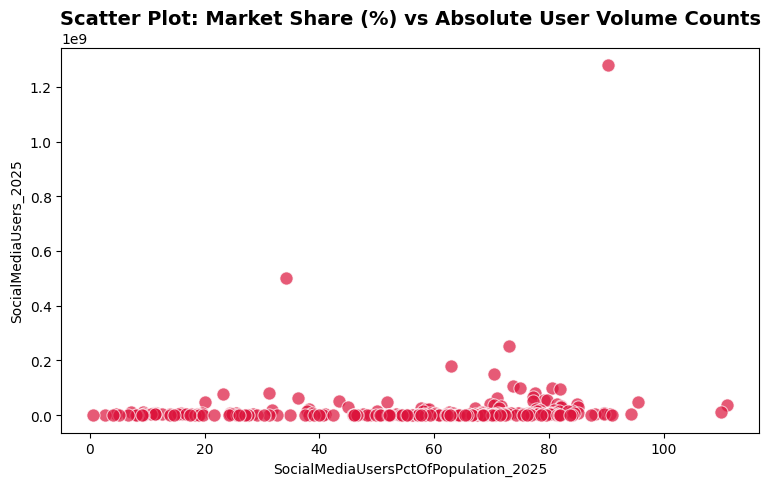

In [20]:
def scatter(x, y, title="Scatter Plot"):
    plt.figure(figsize=(9, 5))
    sns.scatterplot(x=x, y=y, alpha=0.7, color='crimson', edgecolor='w', s=90)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.show()
scatter(x=df['SocialMediaUsersPctOfPopulation_2025'], y=df['SocialMediaUsers_2025'],title="Scatter Plot: Market Share (%) vs Absolute User Volume Counts")

In [23]:
#choropleth map
fig = px.choropleth(df, locations="flagCode",
                    color="SocialMediaUsersPctOfPopulation_2025",hover_name="country",
                    color_continuous_scale=px.colors.sequential.Plasma,title="Choropleth Map: Global Market Share Penetration %")
fig.show()

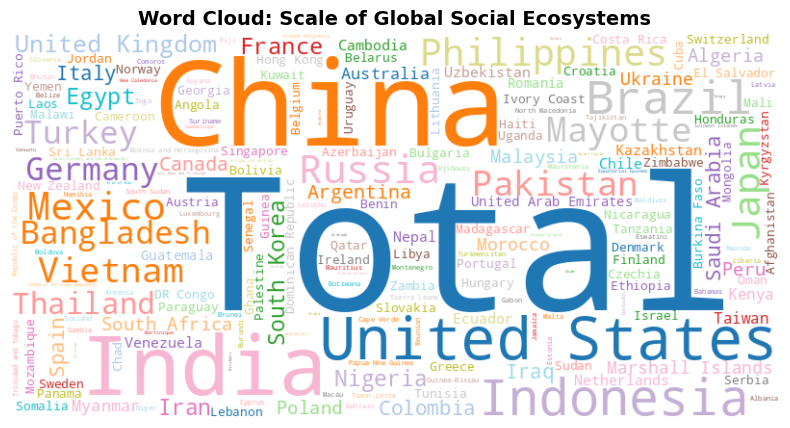

In [24]:
#world cloud
cloud_dictionary = dict(zip(df['country'], df['SocialMediaUsers_2025']))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20').generate_from_frequencies(cloud_dictionary)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud: Scale of Global Social Ecosystems", fontsize=14, fontweight='bold')
plt.show()

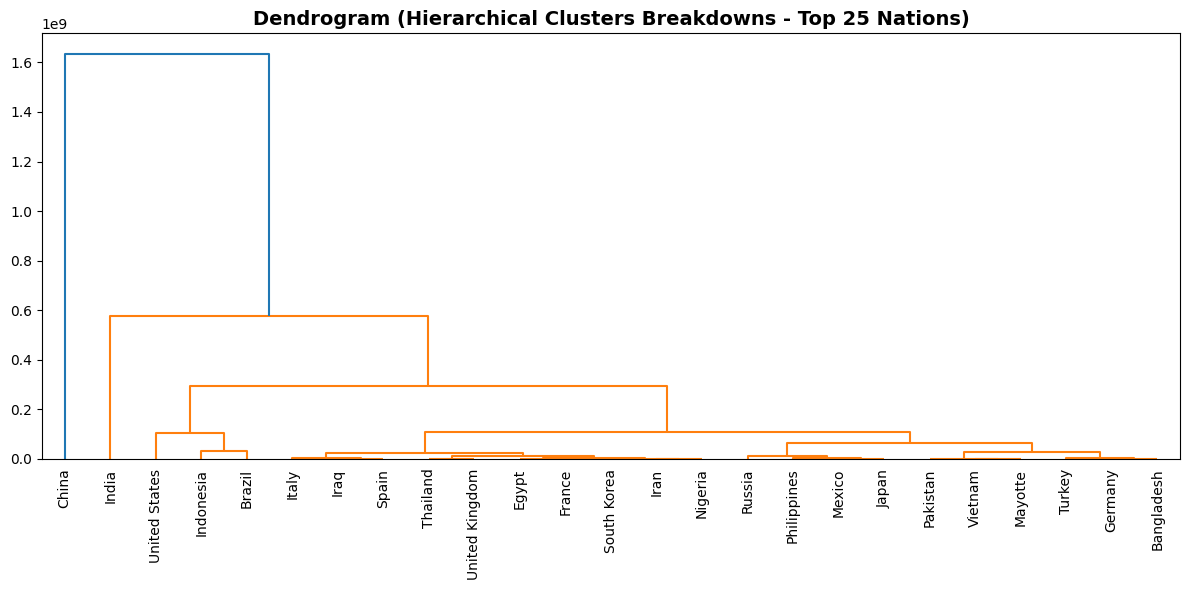

In [26]:
#dendograms
plt.figure(figsize=(12, 6))
dendrogram_data = df[['SocialMediaUsers_2025', 'SocialMediaUsersPctOfPopulation_2025']].head(25)
linked_matrix = linkage(dendrogram_data, method='ward')
dendrogram(linked_matrix, labels=df['country'].head(25).values, orientation='top', leaf_rotation=90)
plt.title("Dendrogram (Hierarchical Clusters Breakdowns - Top 25 Nations)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

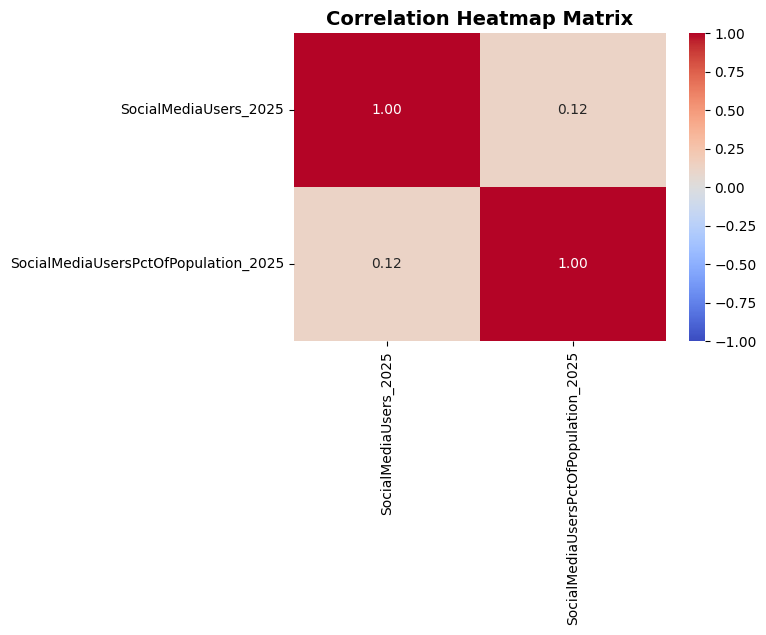

In [27]:
# correlation heat map
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap Matrix", fontsize=14, fontweight='bold')
plt.show()

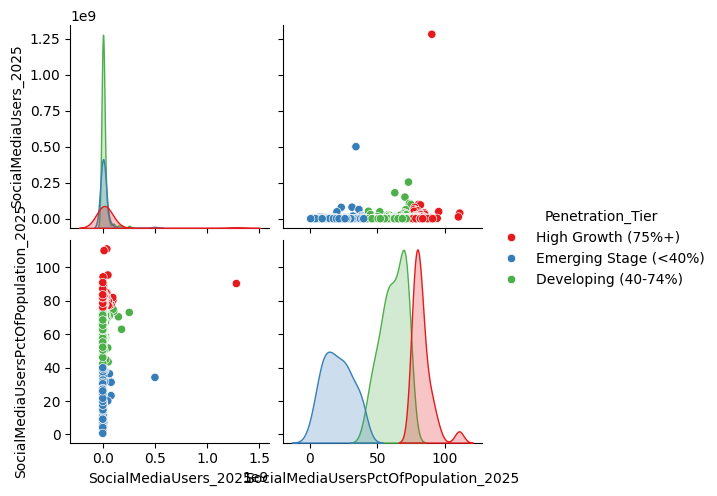

In [31]:
#pair plots
sns.pairplot(df[['SocialMediaUsers_2025', 'SocialMediaUsersPctOfPopulation_2025', 'Penetration_Tier']],
hue='Penetration_Tier', palette='Set1')
plt.show()

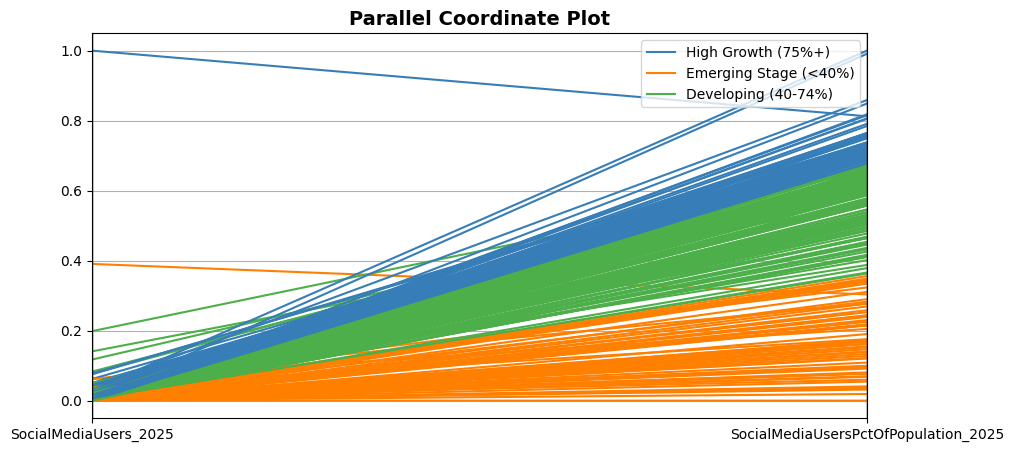

In [34]:
# Parallel coordinate
plt.figure(figsize=(10, 5))
df_norm = df[['SocialMediaUsers_2025', 'SocialMediaUsersPctOfPopulation_2025', 'Penetration_Tier']].copy()
for col in ['SocialMediaUsers_2025', 'SocialMediaUsersPctOfPopulation_2025']:
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

parallel_coordinates(df_norm, 'Penetration_Tier', color=('#377eb8', '#ff7f00', '#4daf4a'))
plt.title("Parallel Coordinate Plot", fontsize=14, fontweight='bold')
plt.show()


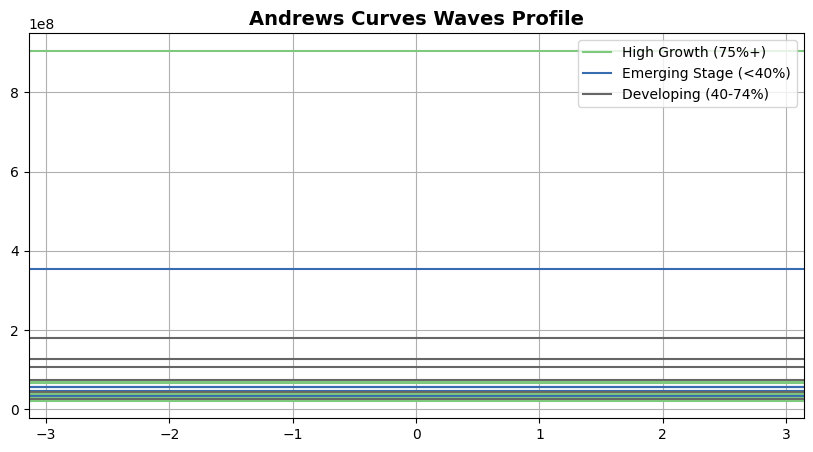

In [35]:
# Andrews Curves
plt.figure(figsize=(10, 5))
andrews_curves(df[['SocialMediaUsers_2025', 'SocialMediaUsersPctOfPopulation_2025', 'Penetration_Tier']].head(30),
               'Penetration_Tier', colormap='Accent')
plt.title("Andrews Curves Waves Profile", fontsize=14, fontweight='bold')
plt.show()
